# Chapter 05 — Model Comparison

This chapter compares four candidate machine learning models for stroke prediction under the highly imbalanced stroke outcome.

The candidate models are:

1. Logistic Regression
2. Logistic Regression with class weighting
3. Random Forest with class weighting
4. XGBoost with class imbalance handling

All models use the same train/test split and preprocessing pipeline to ensure a fair comparison. Model performance is evaluated using recall, precision, F1-score, and ROC-AUC, with particular emphasis on the minority stroke class.

The goal is to identify the most promising models for further refinement.

## 1. Data Preparation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier

In [4]:
# load the data
data_path = "../data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)
df = df.drop(columns="id")
df = df[df["gender"] != "Other"]

# split the data into features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# define the preprocessing pipelines for numeric and categorical features
numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
binary_features = ["hypertension", "heart_disease"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [5]:
print("Training set:")
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts(normalize=True))

Training set:
stroke
0    0.951309
1    0.048691
Name: proportion, dtype: float64

Test set:
stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64


All models use the same stratified train/test split and preprocessing pipeline to ensure that differences in performance are attributable to the models rather than differences in data preparation.

## 2. Candidate Models

Four models with different approaches to the imbalanced classification problem were evaluated

In [7]:
# basline logistic regression model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [8]:
# logistic regression model with class_weight="balanced"
balanced_logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

In [9]:
# random forest model with class_weight="balanced"
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [10]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

scale_pos_weight

np.float64(19.537688442211056)

The scale_pos_weight parameter was calculated from the training data to account for the imbalance between non-stroke and stroke cases.

In [11]:
# xgboost model with calculated weight
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

## 3. Model Evaluation

In [12]:
# store all models in a dictionary for easy access
models = {
    "Logistic Regression": logistic_model,
    "Balanced Logistic Regression": balanced_logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

In [13]:
models.keys()

dict_keys(['Logistic Regression', 'Balanced Logistic Regression', 'Random Forest', 'XGBoost'])

In [14]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("All models trained.")

Training Logistic Regression...
Training Balanced Logistic Regression...
Training Random Forest...
Training XGBoost...
All models trained.


In [15]:
predictions = {}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [16]:
def evaluate_model(model, X_test, y_test, model_name=None, plot_cm=True):

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, y_prob)
        ]
    })

    metrics["Score"] = metrics["Score"].round(3)

    if model_name:
        print(f"\n{'='*50}")
        print(f"{model_name}")
        print(f"{'='*50}")

    print(metrics)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    if plot_cm:
        ConfusionMatrixDisplay(
            confusion_matrix=cm
        ).plot(cmap="Blues")

        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()

    return {
        "metrics": metrics,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm
    }

## 4. Model Performance Comparison

In [17]:
evaluation_results = {}

for name, model in models.items():

    evaluation_results[name] = evaluate_model(
        model,
        X_test,
        y_test,
        model_name=name,
        plot_cm=False
    )


Logistic Regression
      Metric  Score
0   Accuracy  0.952
1  Precision  1.000
2     Recall  0.020
3   F1-score  0.039
4    ROC-AUC  0.839

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022


Balanced Logistic Regression
      Metric  Score
0   Accuracy  0.739
1  Precision  0.135
2     Recall  0.800
3   F1-score  0.231
4    ROC-AUC  0.839

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022


Random

In [18]:
comparison = []

for name, result in evaluation_results.items():

    scores = result["metrics"].set_index("Metric")["Score"]

    comparison.append({
        "Model": name,
        "Accuracy": scores["Accuracy"],
        "Precision": scores["Precision"],
        "Recall": scores["Recall"],
        "F1-score": scores["F1-score"],
        "ROC-AUC": scores["ROC-AUC"]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.952,1.000,0.02,0.039,0.839
1,Balanced Logistic Regression,0.739,0.135,0.80,0.231,0.839
2,Random Forest,0.939,0.227,0.10,0.139,0.783
3,XGBoost,0.804,0.150,0.64,0.242,0.815


### Initial Findings

* The unweighted Logistic Regression model achieved a high ROC-AUC of 0.839 and accuracy of 0.952, but its recall for stroke cases was only 0.020. This means that the model identified very few of the actual stroke cases despite its high overall accuracy.

* Applying class weighting substantially improved Logistic Regression recall from 0.020 to 0.800, although precision decreased from 1 to 0.135. This demonstrates the impact of class weighting on prioritizing the minority stroke class.

* Random Forest performed less well in this initial configuration, with a ROC-AUC of 0.783 and recall of 0.100.

* XGBoost achieved a recall of 0.640 and the highest F1-score among the four initial models (0.242), but its ROC-AUC of 0.815 was lower than both Logistic Regression models.

Overall, the results suggest that Balanced Logistic Regression and XGBoost are the most promising candidates for further refinement.


## 5. ROC Curve

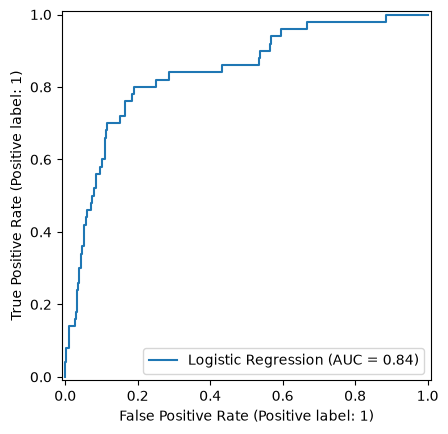

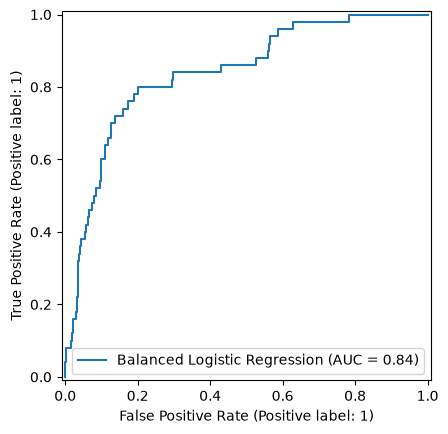

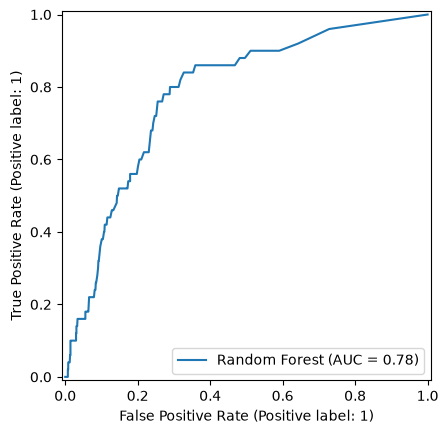

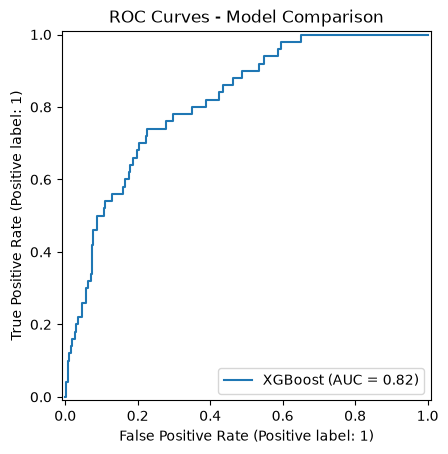

In [19]:
for name, result in evaluation_results.items():

    RocCurveDisplay.from_predictions(
        y_test,
        result["y_prob"],
        name=name
    )

plt.title("ROC Curves - Model Comparison")
plt.show()

The ROC curves provide a threshold-independent comparison of the models' ability to distinguish between stroke and non-stroke cases.

The two Logistic Regression models show similar discrimination, while Random Forest and XGBoost perform less well in this initial configuration.

## 6. Precision-Recall Curve

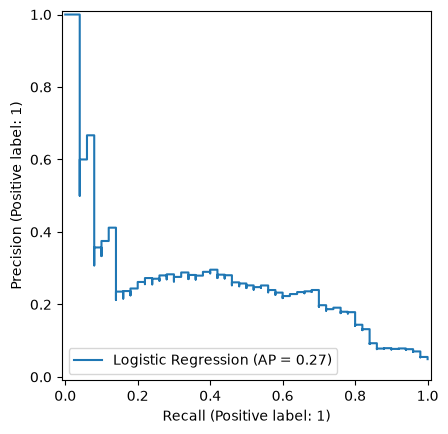

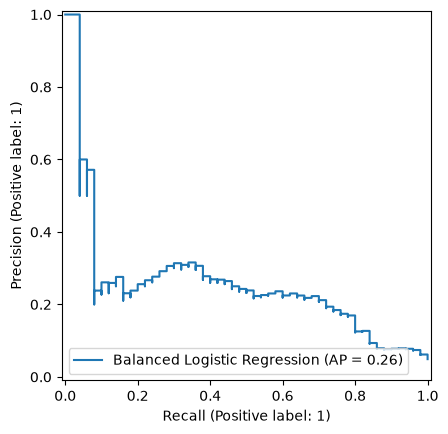

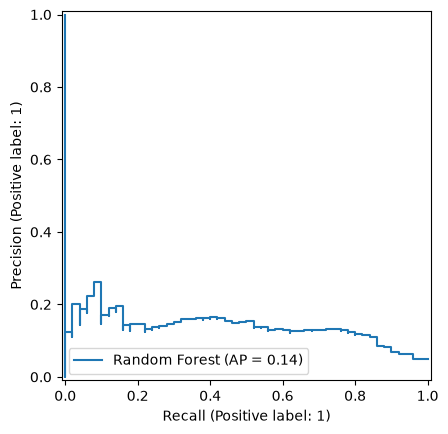

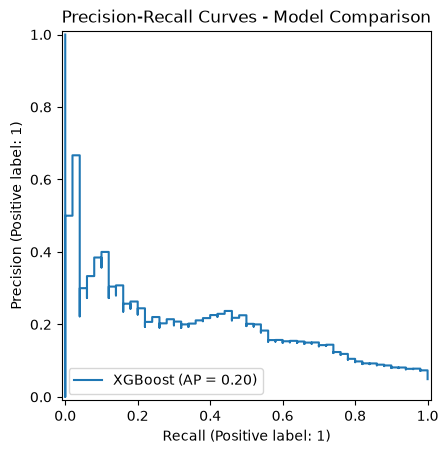

In [20]:
for name, result in evaluation_results.items():

    PrecisionRecallDisplay.from_predictions(
        y_test,
        result["y_prob"],
        name=name
    )

plt.title("Precision-Recall Curves - Model Comparison")
plt.show()

Because stroke is the minority class, the Precision-Recall curves provide an important complementary view of model performance.

The curves illustrate the trade-off between precision and recall across different classification thresholds. Models that maintain higher precision while achieving high recall are generally more useful when the goal is to identify stroke cases while limiting false-positive predictions.


## 7. Error and Metric

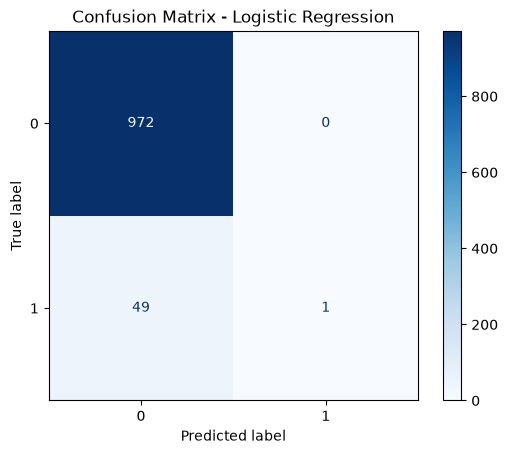

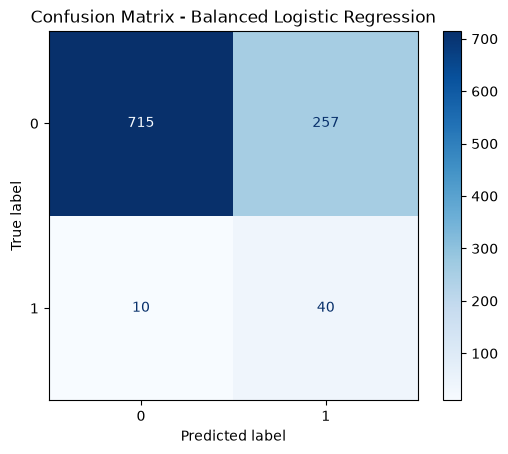

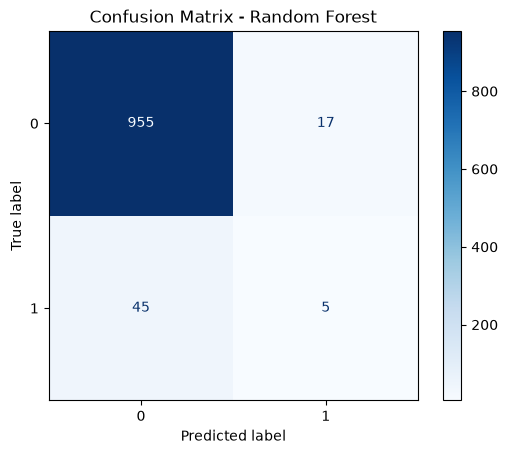

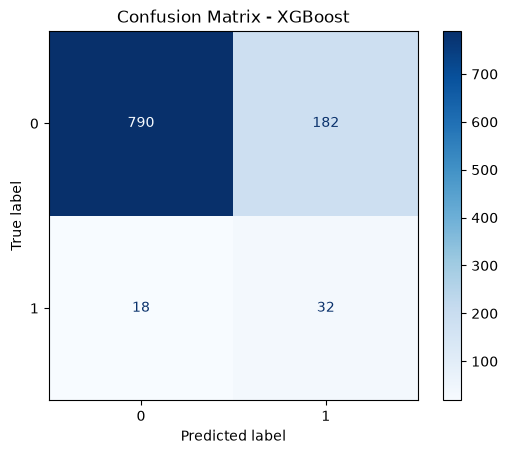

In [23]:
for name, result in evaluation_results.items():

    ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"]
    ).plot(cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

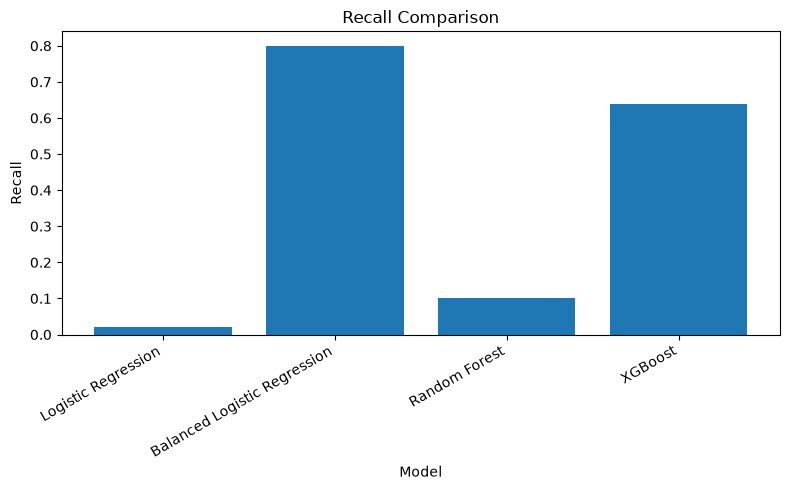

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"]
)

plt.ylabel("Recall")
plt.xlabel("Model")
plt.title("Recall Comparison")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

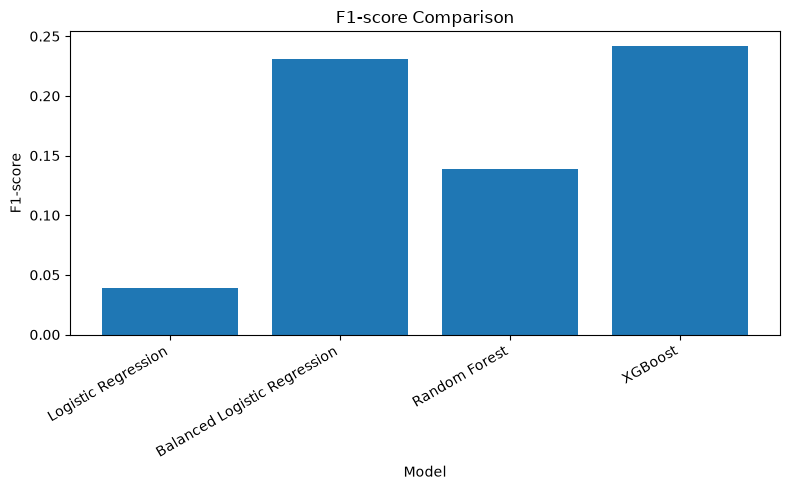

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1-score"]
)

plt.ylabel("F1-score")
plt.xlabel("Model")
plt.title("F1-score Comparison")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

The confusion matrices and metric comparisons further illustrate the effect of class imbalance. The unweighted Logistic Regression model produces very few false positives but misses most stroke cases, whereas class weighting substantially increases stroke detection.

Among the initial models, Balanced Logistic Regression provides the strongest recall, while XGBoost achieves a slightly higher F1-score. These results reinforce the importance of considering multiple metrics rather than accuracy alone.

In [26]:
comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.952,1.000,0.02,0.039,0.839
1,Balanced Logistic Regression,0.739,0.135,0.80,0.231,0.839
2,Random Forest,0.939,0.227,0.10,0.139,0.783
3,XGBoost,0.804,0.150,0.64,0.242,0.815


## 8. Summary

The initial model comparison identifies Balanced Logistic Regression and XGBoost as the two most promising candidates for further refinement.

However, these results are preliminary because the models have not yet undergone systematic hyperparameter tuning and cross-validation. In addition, classification performance depends on the selected probability threshold.

Chapter 06 therefore focuses on refining these two models, comparing their performance using cross-validation and held-out test data, and selecting the final model for further analysis.